In [59]:
import pandas as pd
import os

In [60]:
# Define the directory containing CSV files
csv_dir = '../result/test/sctab/scVI-classification-evals-for-different-k-and-epoch/'

# Define expected columns
columns = ['accuracy', 'precision', 'recall', 'micro_f1', 'macro_f1', 'seed', 'dataset', 'ARtype', 'latent_dim', 'Atlas_cell_count', 'epoch_num']

# Initialize an empty list to store DataFrames
df_list = []

# Loop over all CSV files in the directory
for file in os.listdir(csv_dir):
    if file.endswith(".csv"):
        file_path = os.path.join(csv_dir, file)
        df_temp = pd.read_csv(file_path, usecols=columns)
        df_list.append(df_temp)

# Concatenate all DataFrames into one
df = pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame(columns=columns)

In [63]:
# remove repeted rows
df = df.drop_duplicates()
df

,accuracy,precision,recall,micro_f1,macro_f1,seed,dataset,ARtype,latent_dim,Atlas_cell_count,epoch_num
0,0.513200,0.489504,0.372822,0.513200,0.388594,60,Neurons,F,64,100,600
1,0.617383,0.561380,0.452215,0.617383,0.474806,70,Kidney,F,128,10,300
2,0.763484,0.745347,0.539891,0.763484,0.578610,50,Heart,F,32,10000,300
3,0.716180,0.594677,0.487586,0.716180,0.512742,60,Heart,T,64,1,150
4,0.645017,0.616110,0.482643,0.645017,0.510896,80,Kidney,T,64,0,600
...,...,...,...,...,...,...,...,...,...,...,...
850,0.672178,0.653259,0.505693,0.672178,0.520371,50,Kidney,T,64,1,150
851,0.680813,0.566685,0.464763,0.680813,0.486982,80,Heart,F,32,1,300
852,0.800472,0.795790,0.640933,0.800472,0.681398,80,Heart,T,64,1000,600
853,0.504800,0.458926,0.375425,0.504800,0.396201,50,Neurons,F,64,1,150


In [64]:
assert df[df['ARtype'] == 'T'].shape[0] == df[df['ARtype'] == 'F'].shape[0]
# assert if the number of rows for each seed is the same
assert df[df['seed'] == 50].shape[0] \
    == df[df['seed'] == 60].shape[0] \
    == df[df['seed'] == 70].shape[0] \
    == df[df['seed'] == 80].shape[0] \
    == df[df['seed'] == 90].shape[0]

In [65]:
df.columns = ['Accuracy', 'Precision', 'Recall', 'Micro F1 Score', 'Macro F1 Score', 'seed', 'dataset', 'ARtype', 'latent_dim', 'Atlas_cell_count', 'epoch_num']

In [66]:
import pandas as pd

# Define metrics and target columns
metrics = ['Accuracy', 'Precision', 'Recall', 'Micro F1 Score', 'Macro F1 Score']
columns = ['dataset', 'metric', 'value', 'ARtype', 'Atlas_cell_count', 'latent_dim', 'epoch_num']
plot_df_list = []

# Loop through each row in df
for index, row in df.iterrows():
    for metric in metrics:
        tmp_df = pd.DataFrame(
            [[row['dataset'], metric, row[metric], row['ARtype'], row['Atlas_cell_count'], row['latent_dim'], row['epoch_num']]],
            columns=columns
        )
        plot_df_list.append(tmp_df)

# Concatenate all DataFrames
plot_df = pd.concat(plot_df_list, ignore_index=True) if plot_df_list else pd.DataFrame(columns=columns)

In [67]:
plot_df = plot_df.sort_values(by='Atlas_cell_count')
plot_df

,dataset,metric,value,ARtype,Atlas_cell_count,latent_dim,epoch_num
1049,Heart,Macro F1 Score,0.512684,F,0,64,150
2878,Heart,Micro F1 Score,0.682729,F,0,32,300
3724,Neurons,Macro F1 Score,0.464837,T,0,64,600
3723,Neurons,Micro F1 Score,0.562400,T,0,64,600
3722,Neurons,Recall,0.448528,T,0,64,600
...,...,...,...,...,...,...,...
3700,Heart,Accuracy,0.822723,F,50000,128,300
3701,Heart,Precision,0.840125,F,50000,128,300
3702,Heart,Recall,0.680086,F,50000,128,300
571,Kidney,Precision,0.705718,F,50000,128,300


In [68]:
# change ARtype to AR and Naive
plot_df['ARtype'] = plot_df['ARtype'].replace({'T': 'AR', 'F': 'Standard'})


=== latent_dim=32, epoch=300 ===
\begin{table}
\caption{P-values for Heart (latent_dim=32, epoch=300)}
\label{tab:pvalues_Heart_32_300}
\begin{tabular}{lrrrrrrr}
Atlas_cell_count & 0 & 1 & 10 & 100 & 1000 & 10000 & 50000 \\
metric &  &  &  &  &  &  &  \\
Accuracy & \background-colorgreen \colorwhite 7.04e-03 & \background-colorgreen \colorwhite 3.25e-04 & \background-colorgreen \colorwhite 8.79e-04 & \background-colorgreen \colorwhite 2.37e-04 & \background-colorgreen \colorwhite 4.90e-05 & \background-colorgreen \colorwhite 5.61e-06 & \background-coloryellow \colorblack 4.65e-01 \\
Macro F1 Score & \background-colorgreen \colorwhite 3.89e-03 & \background-coloryellow \colorblack 5.75e-02 & \background-colorgreen \colorwhite 1.02e-02 & \background-colorgreen \colorwhite 9.16e-05 & \background-colorgreen \colorwhite 2.09e-04 & \background-colorgreen \colorwhite 7.89e-05 & \background-coloryellow \colorblack 3.67e-01 \\
Micro F1 Score & \background-colorgreen \colorwhite 7.04e-03 & \bac

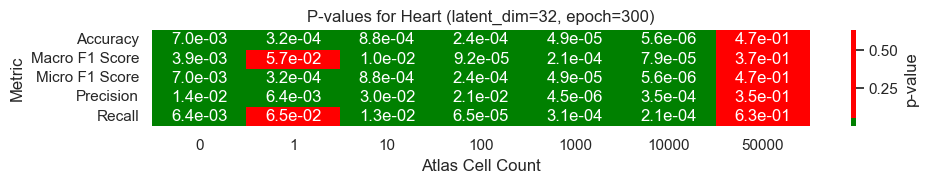

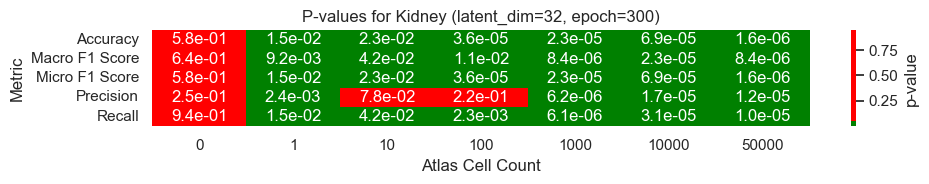

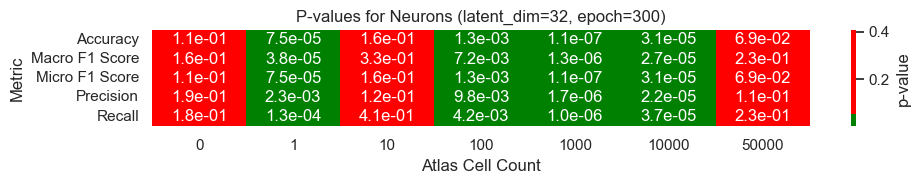


=== latent_dim=64, epoch=150 ===
\begin{table}
\caption{P-values for Heart (latent_dim=64, epoch=150)}
\label{tab:pvalues_Heart_64_150}
\begin{tabular}{lrrrrrrr}
Atlas_cell_count & 0 & 1 & 10 & 100 & 1000 & 10000 & 50000 \\
metric &  &  &  &  &  &  &  \\
Accuracy & \background-coloryellow \colorblack 1.52e-01 & \background-coloryellow \colorblack 8.46e-02 & \background-coloryellow \colorblack 3.43e-01 & \background-colorgreen \colorwhite 6.51e-03 & \background-colorgreen \colorwhite 1.97e-04 & \background-colorgreen \colorwhite 7.34e-06 & \background-colorgreen \colorwhite 7.88e-03 \\
Macro F1 Score & \background-colorgreen \colorwhite 3.38e-02 & \background-coloryellow \colorblack 1.03e-01 & \background-coloryellow \colorblack 4.17e-01 & \background-colorgreen \colorwhite 6.33e-03 & \background-colorgreen \colorwhite 7.05e-04 & \background-colorgreen \colorwhite 4.34e-08 & \background-colorgreen \colorwhite 4.57e-03 \\
Micro F1 Score & \background-coloryellow \colorblack 1.52e-01 & \

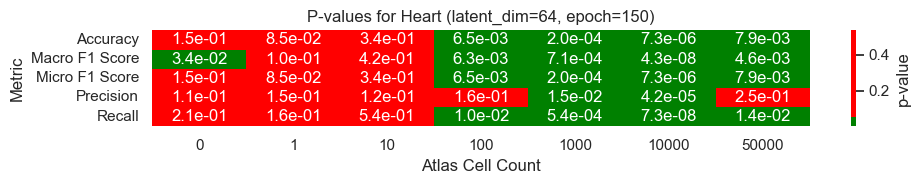

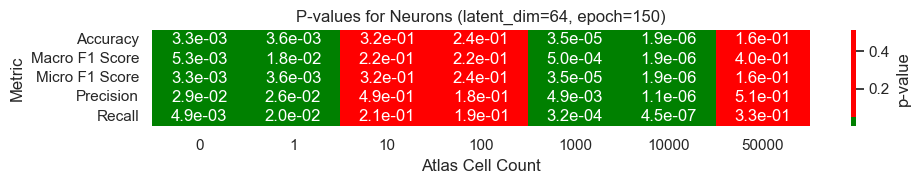

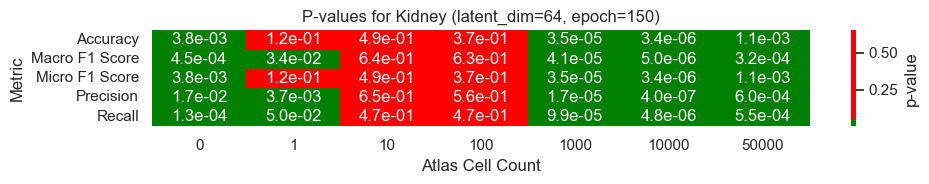


=== latent_dim=64, epoch=600 ===
\begin{table}
\caption{P-values for Neurons (latent_dim=64, epoch=600)}
\label{tab:pvalues_Neurons_64_600}
\begin{tabular}{lrrrrrrr}
Atlas_cell_count & 0 & 1 & 10 & 100 & 1000 & 10000 & 50000 \\
metric &  &  &  &  &  &  &  \\
Accuracy & \background-colorgreen \colorwhite 2.02e-03 & \background-colorgreen \colorwhite 1.08e-02 & \background-colorgreen \colorwhite 3.46e-03 & \background-colorgreen \colorwhite 1.07e-05 & \background-colorgreen \colorwhite 2.38e-08 & \background-colorgreen \colorwhite 1.22e-05 & \background-coloryellow \colorblack 2.70e-01 \\
Macro F1 Score & \background-colorgreen \colorwhite 1.19e-03 & \background-colorgreen \colorwhite 8.81e-03 & \background-colorgreen \colorwhite 1.05e-02 & \background-colorgreen \colorwhite 1.86e-05 & \background-colorgreen \colorwhite 3.58e-08 & \background-colorgreen \colorwhite 3.48e-06 & \background-coloryellow \colorblack 9.74e-01 \\
Micro F1 Score & \background-colorgreen \colorwhite 2.02e-03 & \

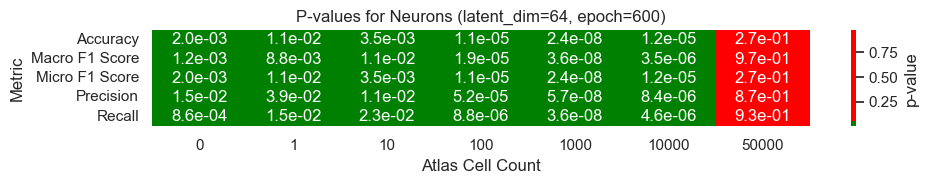

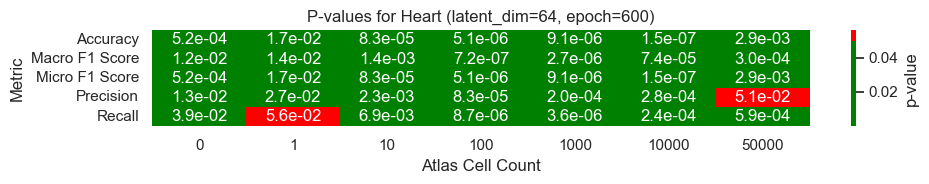

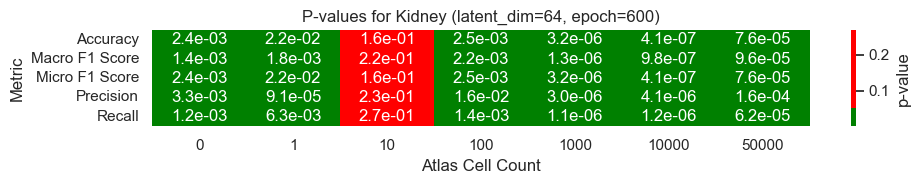


=== latent_dim=128, epoch=300 ===
\begin{table}
\caption{P-values for Kidney (latent_dim=128, epoch=300)}
\label{tab:pvalues_Kidney_128_300}
\begin{tabular}{lrrrrrrr}
Atlas_cell_count & 0 & 1 & 10 & 100 & 1000 & 10000 & 50000 \\
metric &  &  &  &  &  &  &  \\
Accuracy & \background-coloryellow \colorblack 5.09e-02 & \background-colorgreen \colorwhite 3.01e-03 & \background-coloryellow \colorblack 1.89e-01 & \background-colorgreen \colorwhite 1.75e-03 & \background-colorgreen \colorwhite 3.38e-04 & \background-colorgreen \colorwhite 3.09e-06 & \background-colorgreen \colorwhite 8.66e-07 \\
Macro F1 Score & \background-colorgreen \colorwhite 3.36e-02 & \background-colorgreen \colorwhite 2.22e-04 & \background-coloryellow \colorblack 5.26e-02 & \background-colorgreen \colorwhite 1.58e-03 & \background-colorgreen \colorwhite 1.00e-04 & \background-colorgreen \colorwhite 4.15e-06 & \background-colorgreen \colorwhite 3.04e-05 \\
Micro F1 Score & \background-coloryellow \colorblack 5.09e-02 

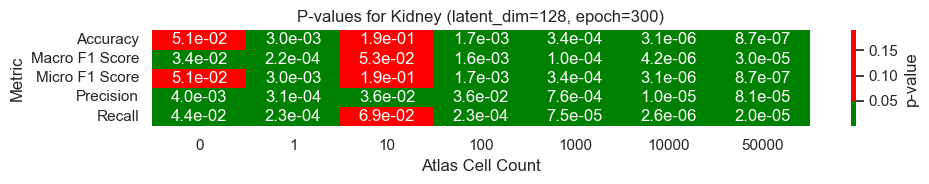

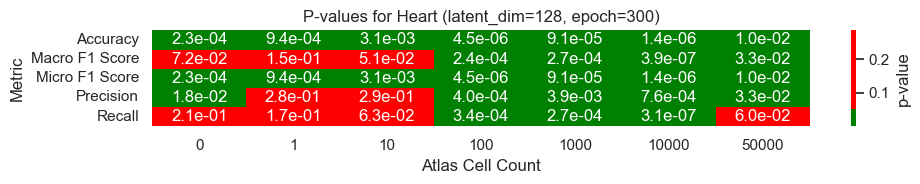

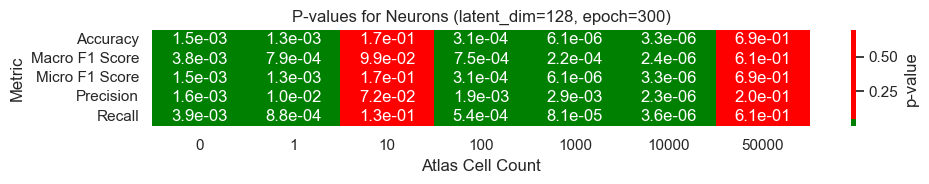

In [69]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

for latent_dim_val, epoch_val in sorted(plot_df[['latent_dim', 'epoch_num']].drop_duplicates().values.tolist()):
    subset = plot_df[(plot_df['latent_dim'] == latent_dim_val) & (plot_df['epoch_num'] == epoch_val)]

    print(f"\n=== latent_dim={latent_dim_val}, epoch={epoch_val} ===")

    # compute p-values between AR and Standard using t-test
    results = []
    for dataset in subset['dataset'].unique():
        for metric in subset['metric'].unique():
            for atlas_cell_count in subset['Atlas_cell_count'].unique():
                ar_values = subset[
                    (subset['dataset'] == dataset) &
                    (subset['metric'] == metric) &
                    (subset['Atlas_cell_count'] == atlas_cell_count) &
                    (subset['ARtype'] == 'AR')
                ]['value']
                naive_values = subset[
                    (subset['dataset'] == dataset) &
                    (subset['metric'] == metric) &
                    (subset['Atlas_cell_count'] == atlas_cell_count) &
                    (subset['ARtype'] == 'Standard')
                ]['value']
                assert ar_values.shape == naive_values.shape
                if len(ar_values) > 1 and len(naive_values) > 1:
                    t_stat, p_value = stats.ttest_ind(ar_values, naive_values)
                    results.append([dataset, metric, atlas_cell_count, p_value])
                else:
                    results.append([dataset, metric, atlas_cell_count, None])

    # print LaTeX table for each dataset
    pval_df = pd.DataFrame(results, columns=['dataset', 'metric', 'Atlas_cell_count', 'p_value'])
    for dataset in pval_df['dataset'].unique():
        sub = pval_df[pval_df['dataset'] == dataset]
        pivot_table = sub.pivot(index='metric', columns='Atlas_cell_count', values='p_value')
        def color_pval(val):
            if pd.isna(val): return ''
            elif val < 0.05: return 'background-color: green; color: white;'
            else: return 'background-color: yellow; color: black;'
        styled_table = pivot_table.style.map(color_pval).format(precision=2, formatter="{:.2e}")
        latex_table = styled_table.to_latex(
            caption=f'P-values for {dataset} (latent_dim={latent_dim_val}, epoch={epoch_val})',
            label=f'tab:pvalues_{dataset}_{latent_dim_val}_{epoch_val}'
        )
        print(latex_table)

    # plot heatmap of p-values
    results_df = pval_df[pval_df['metric'].isin(['Accuracy', 'Precision', 'Recall', 'Micro F1 Score', 'Macro F1 Score'])]
    for dataset in results_df['dataset'].unique():
        pivot_df = results_df[results_df['dataset'] == dataset].pivot(
            index='metric', columns='Atlas_cell_count', values='p_value'
        )
        plt.figure(figsize=(10, 2))
        sns.heatmap(pivot_df, annot=True, fmt=".1e",
                    cmap=sns.color_palette(["green", "red"]), center=0.05,
                    cbar_kws={'label': 'p-value'})
        plt.title(f'P-values for {dataset} (latent_dim={latent_dim_val}, epoch={epoch_val})')
        plt.xlabel('Atlas Cell Count')
        plt.ylabel('Metric')
        plt.tight_layout()
        plt.show()

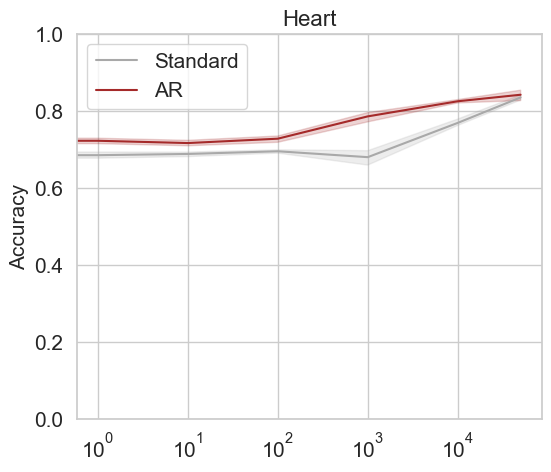

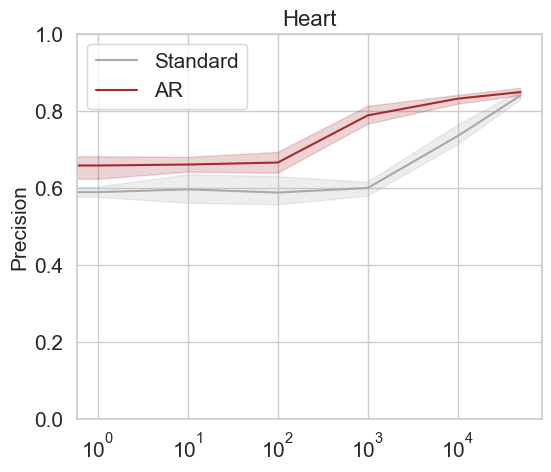

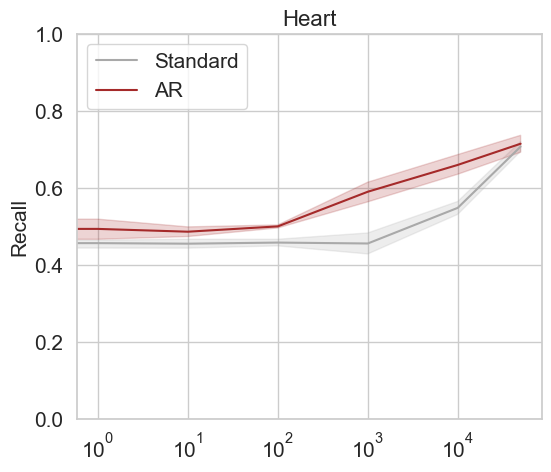

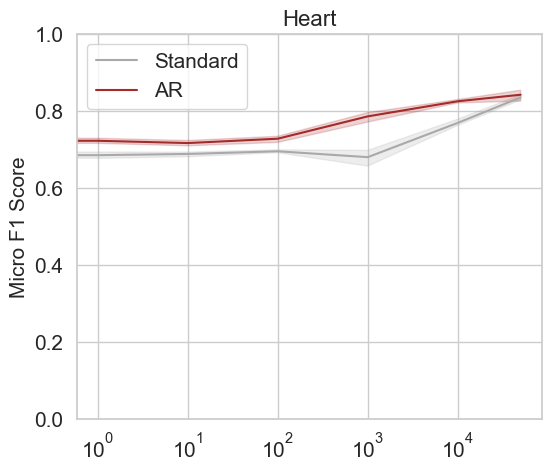

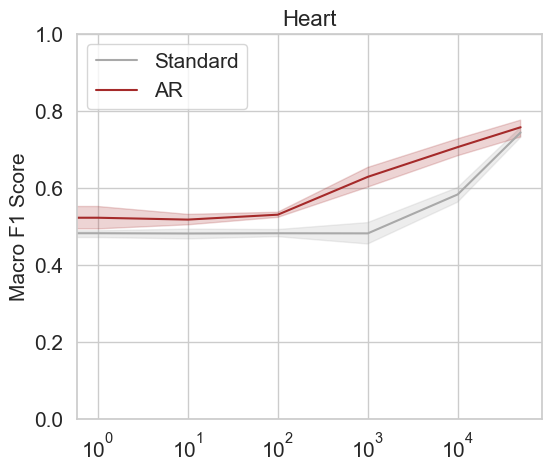

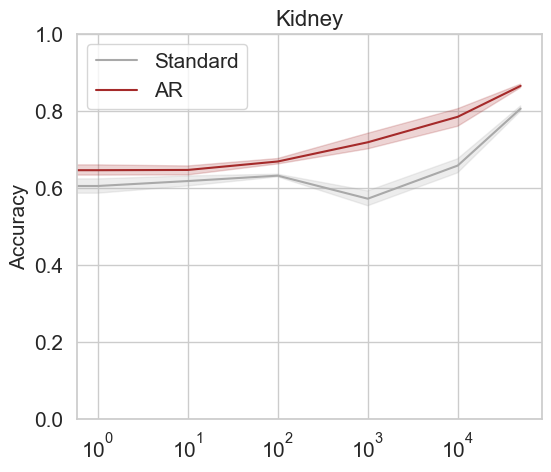

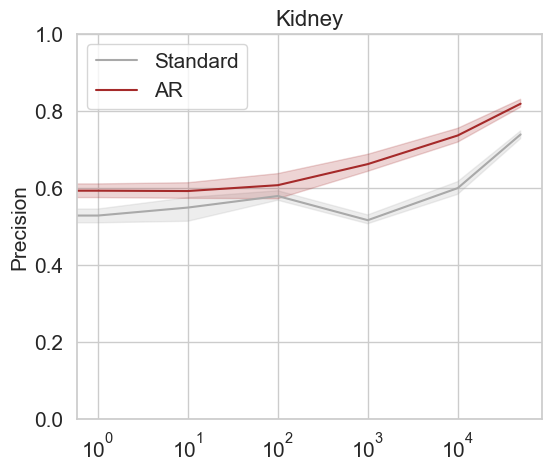

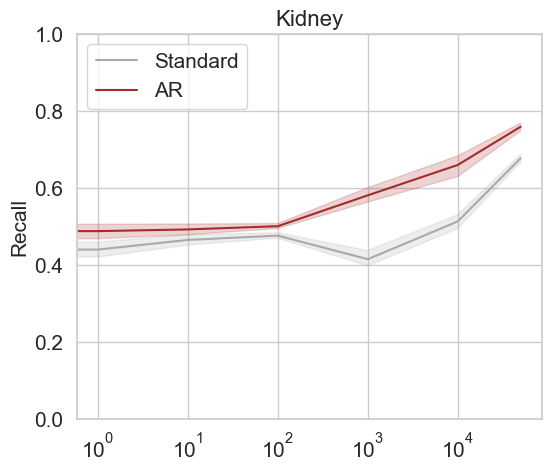

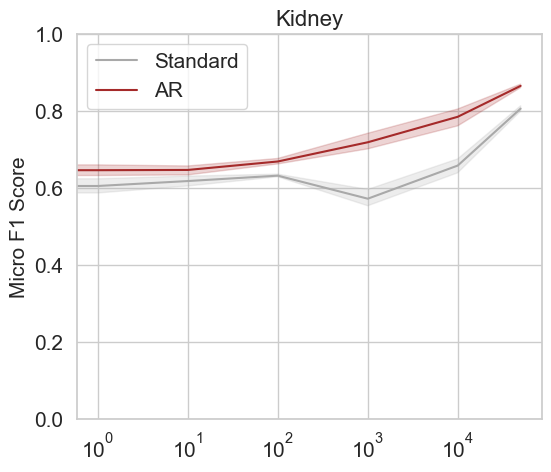

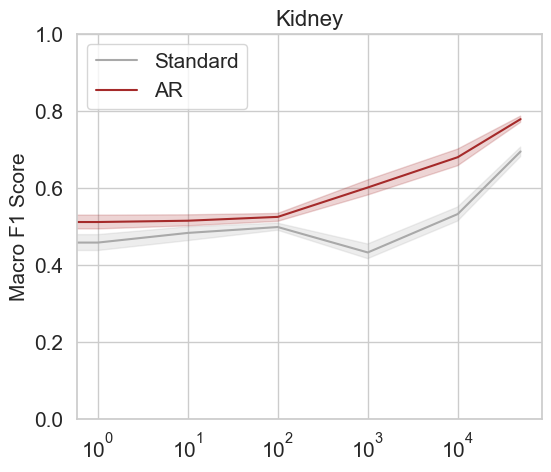

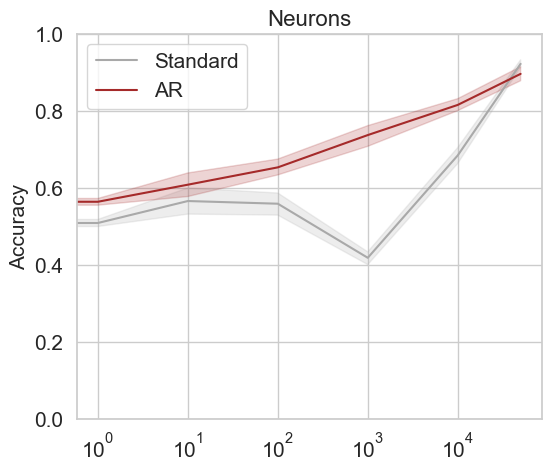

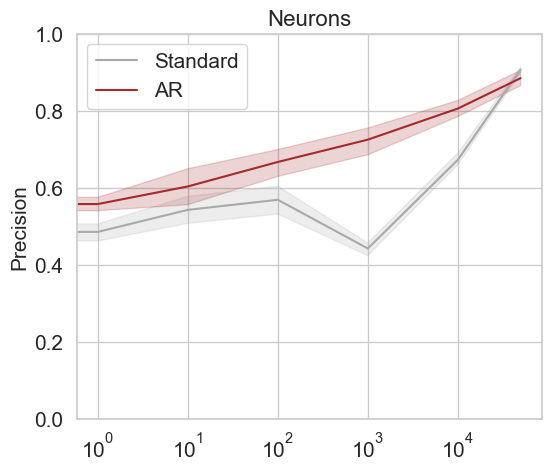

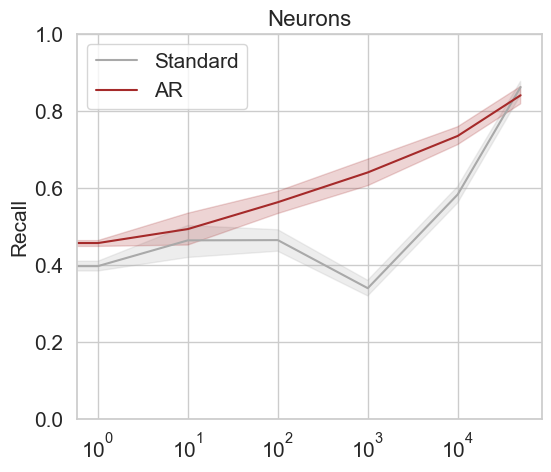

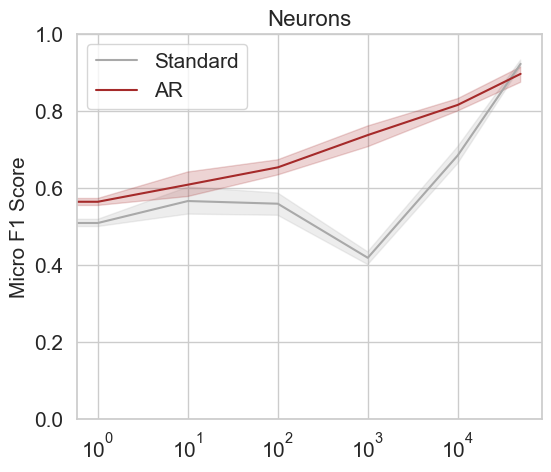

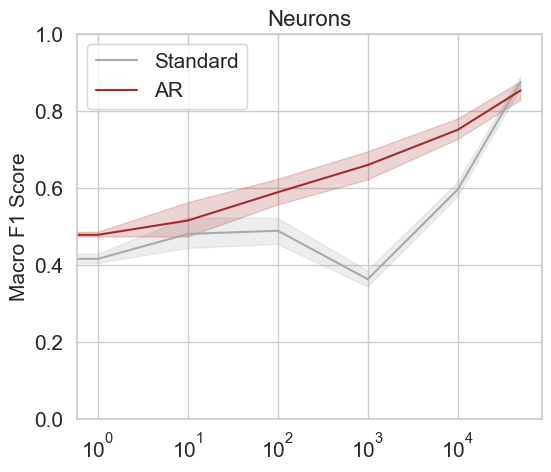

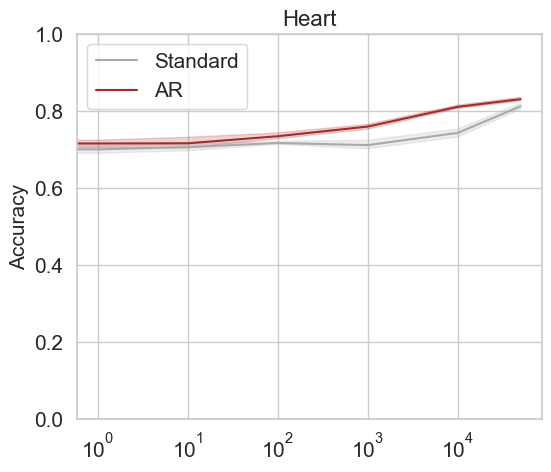

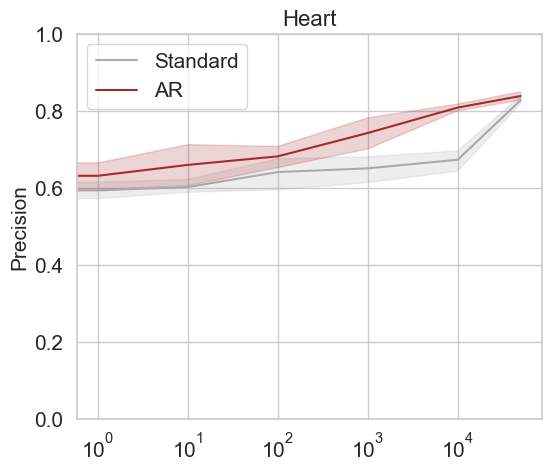

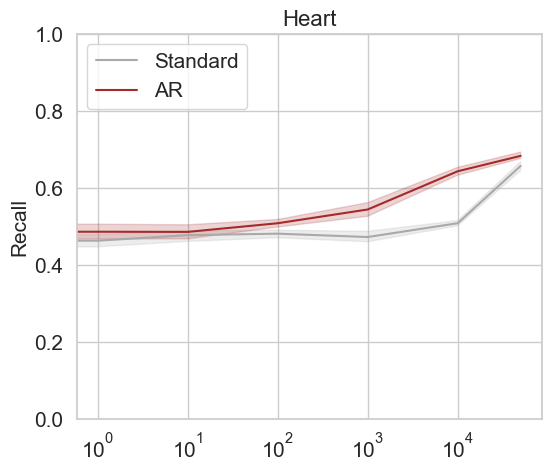

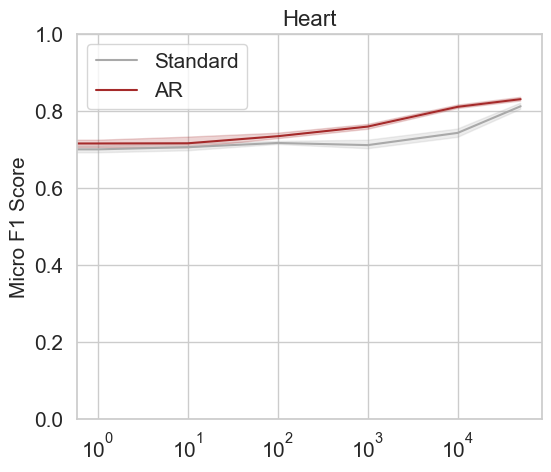

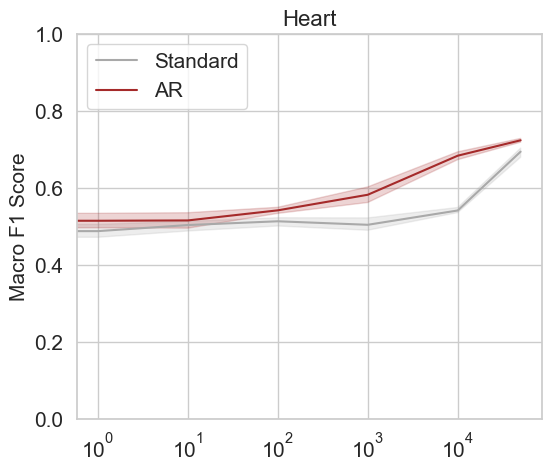

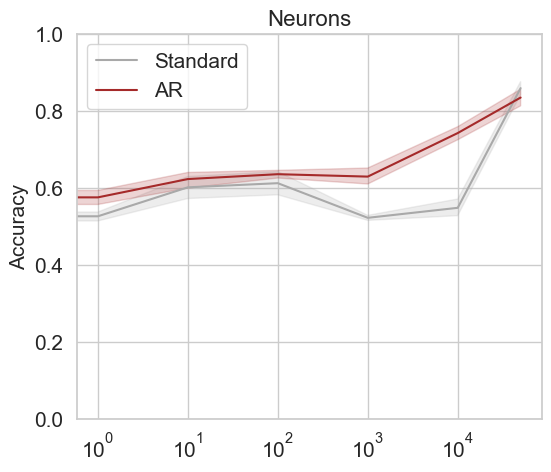

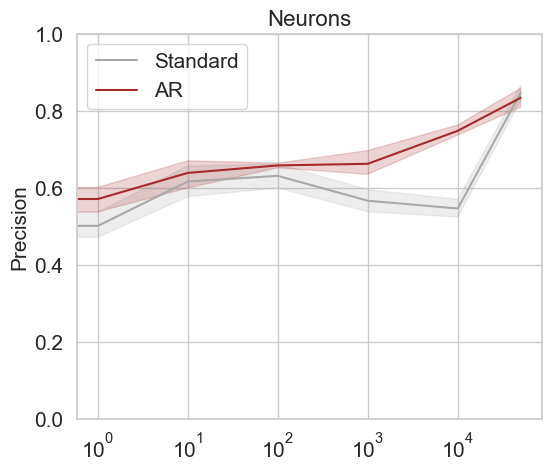

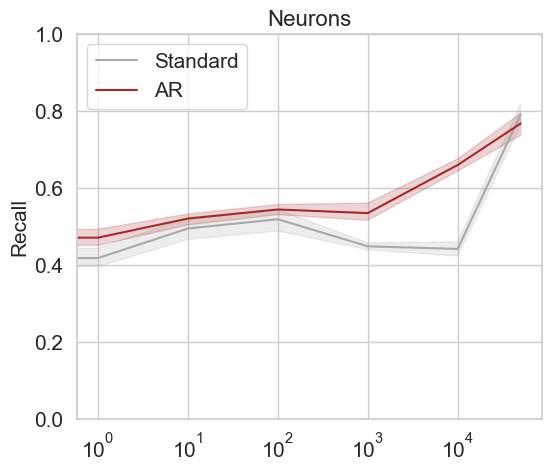

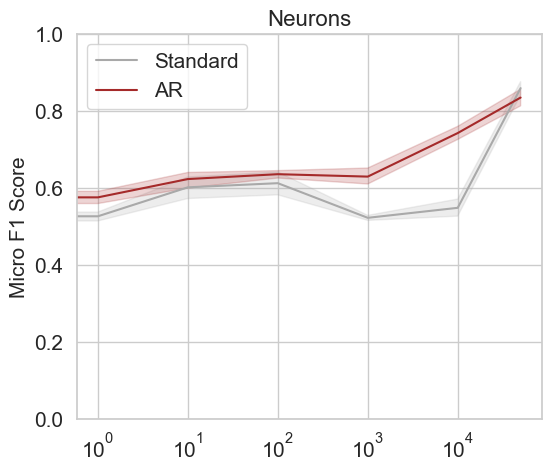

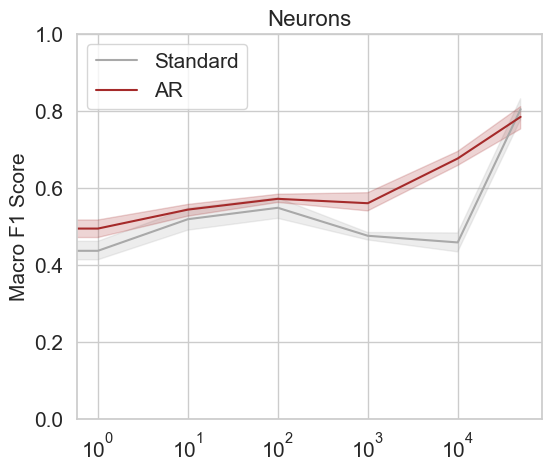

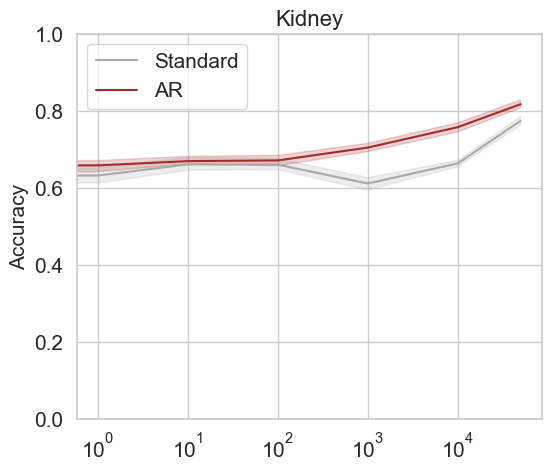

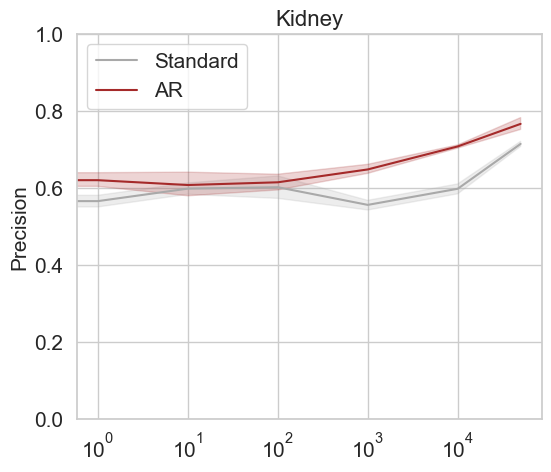

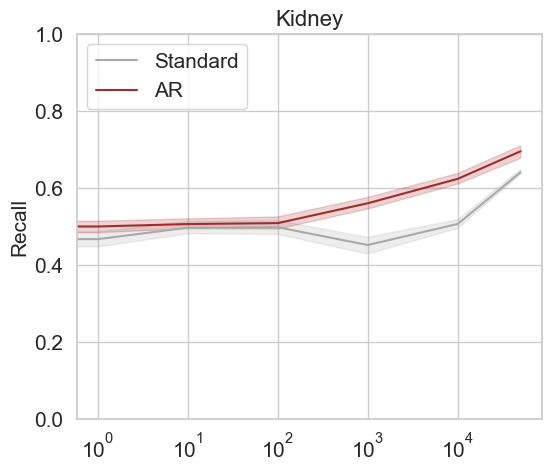

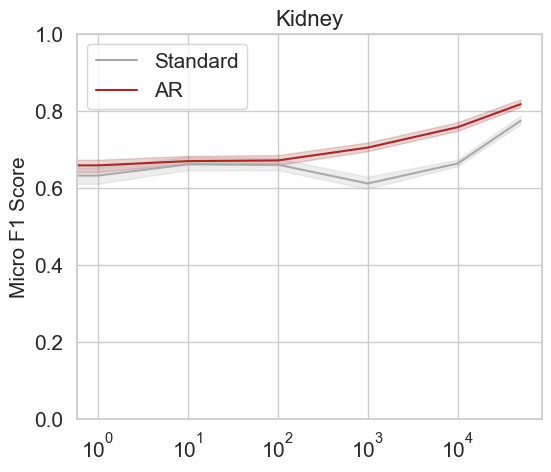

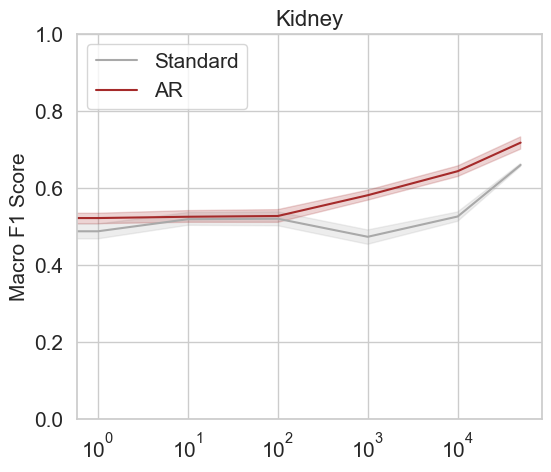

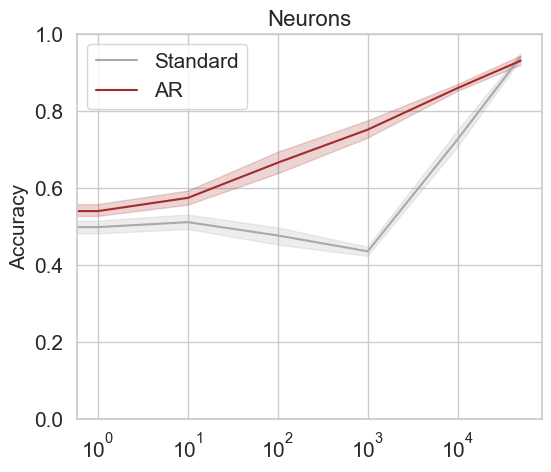

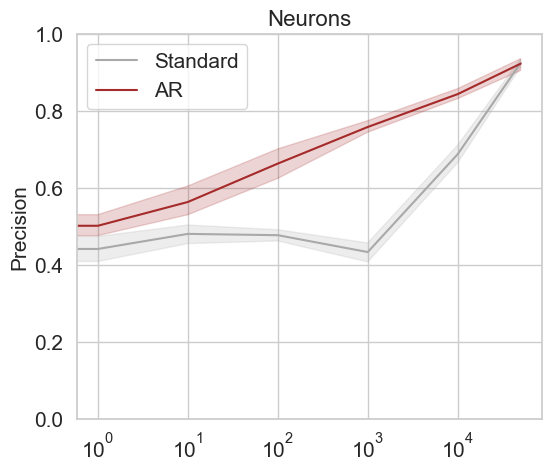

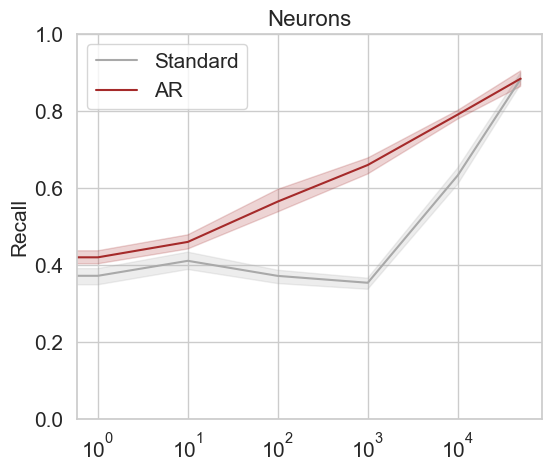

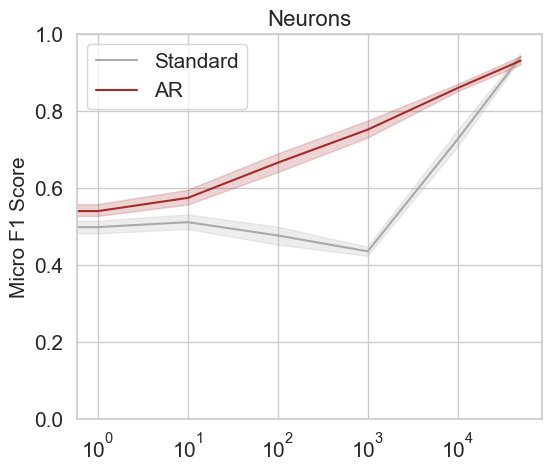

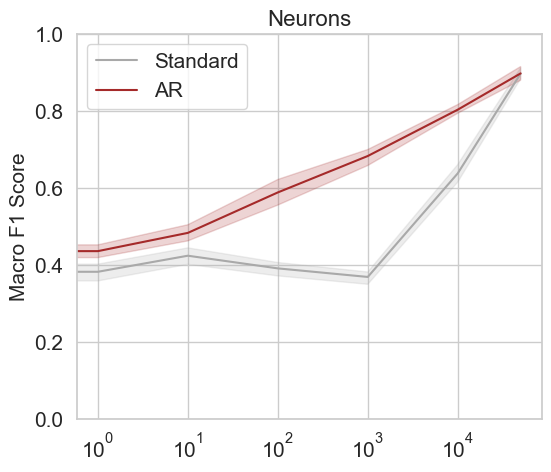

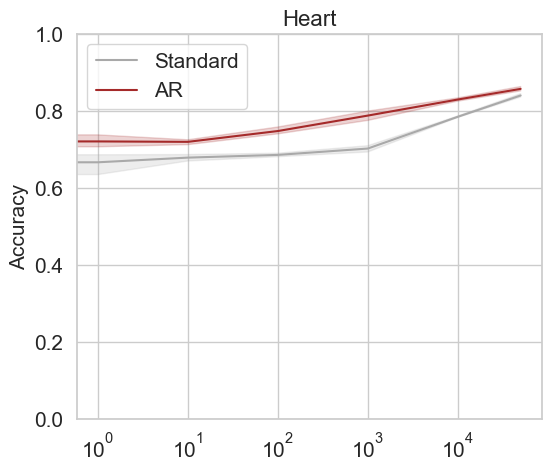

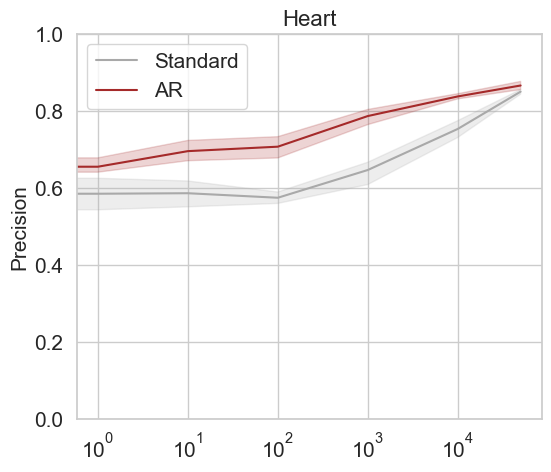

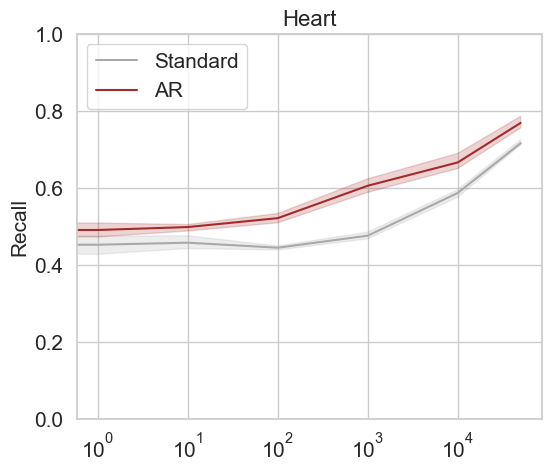

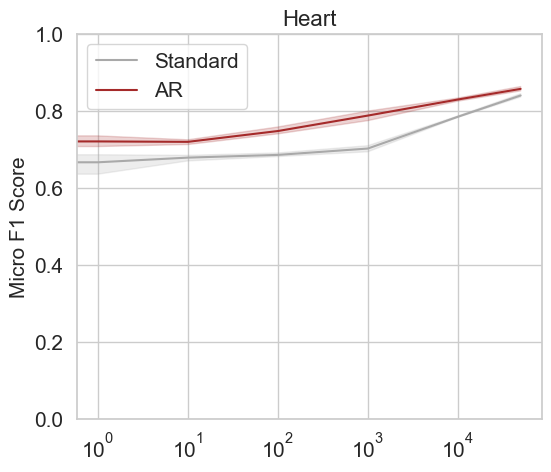

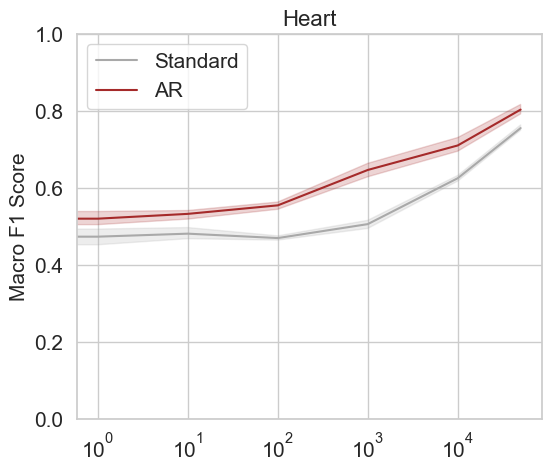

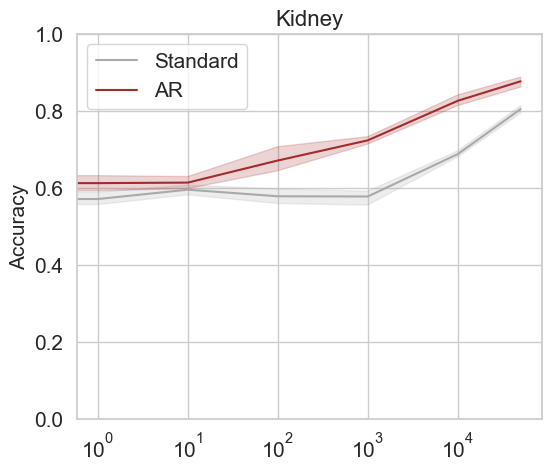

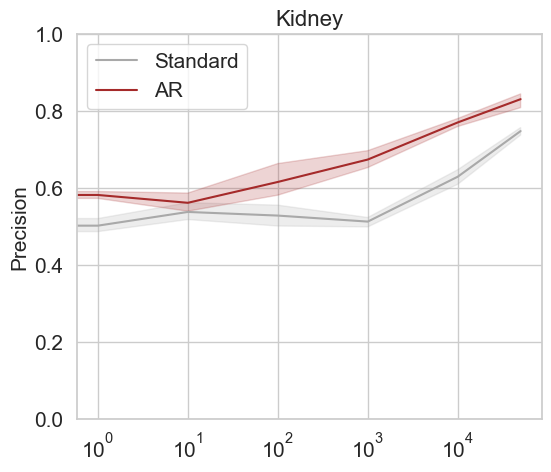

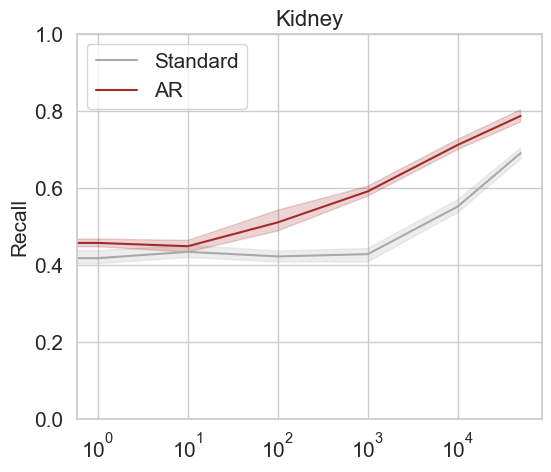

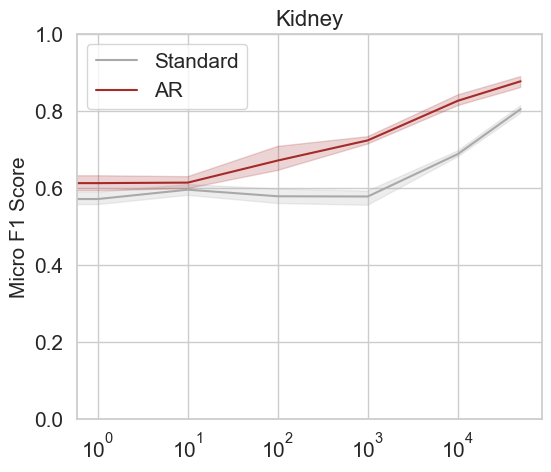

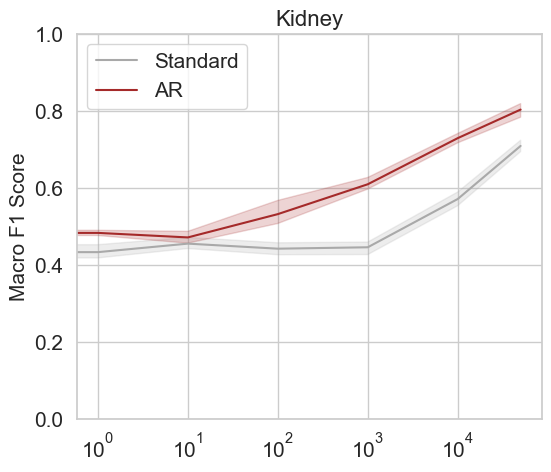

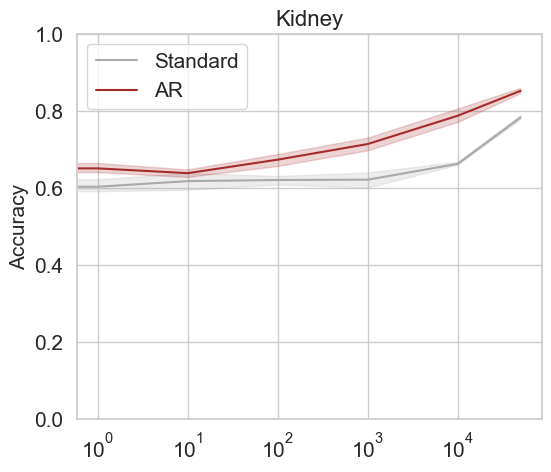

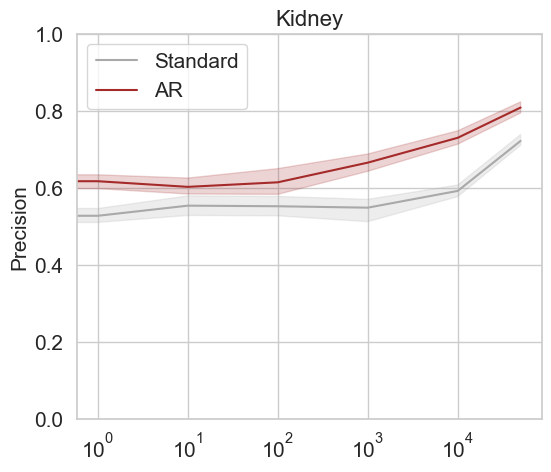

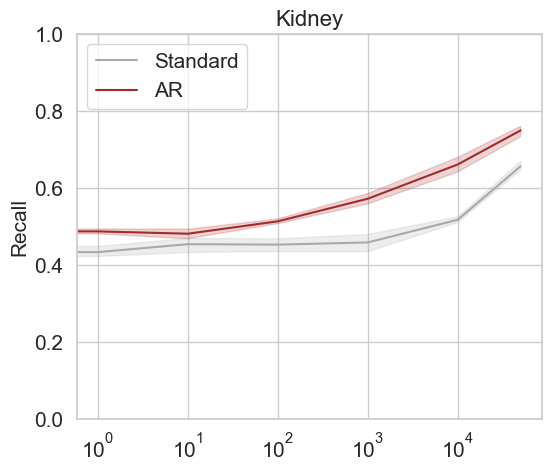

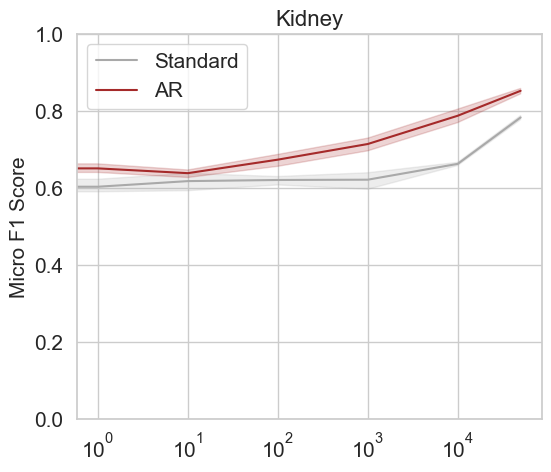

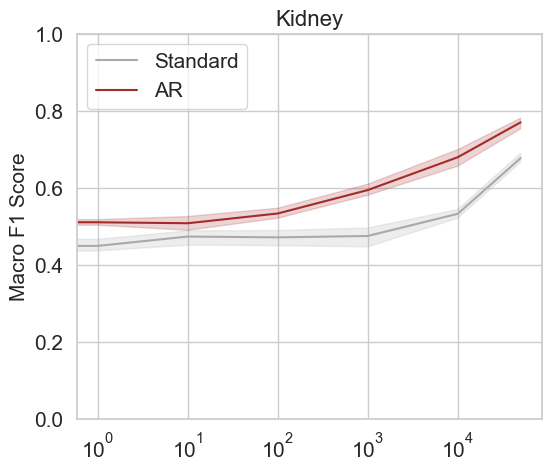

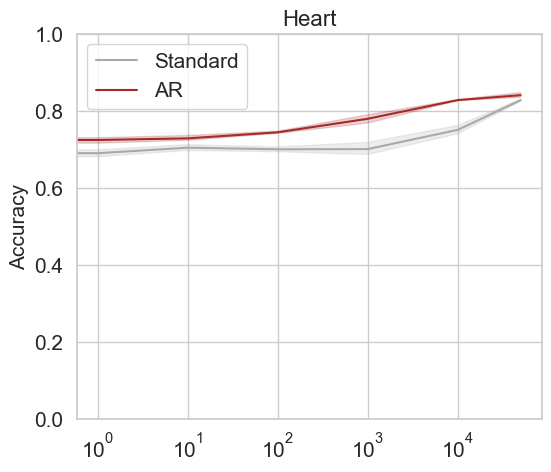

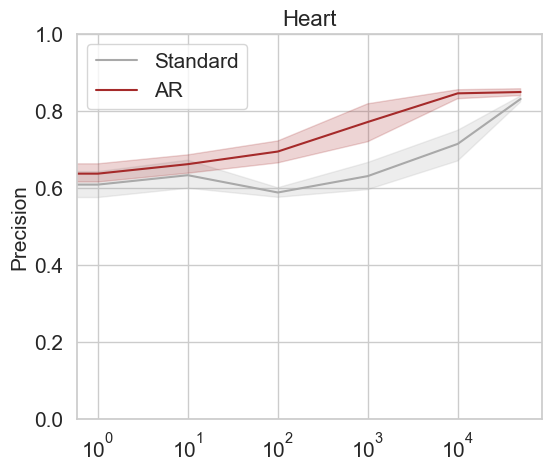

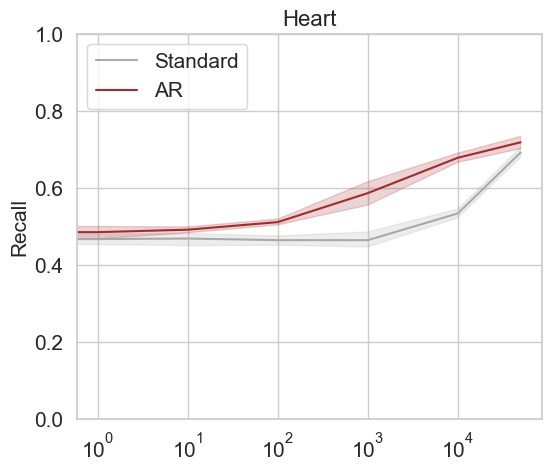

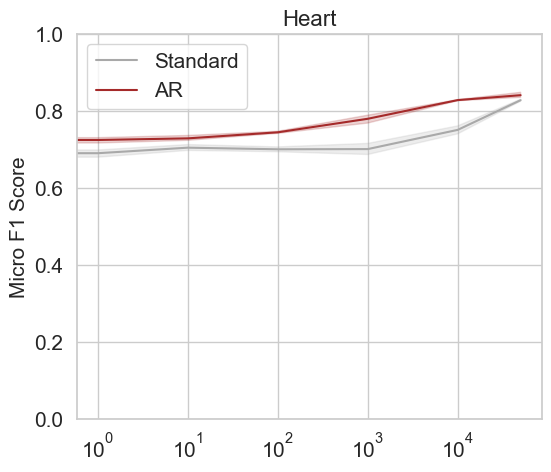

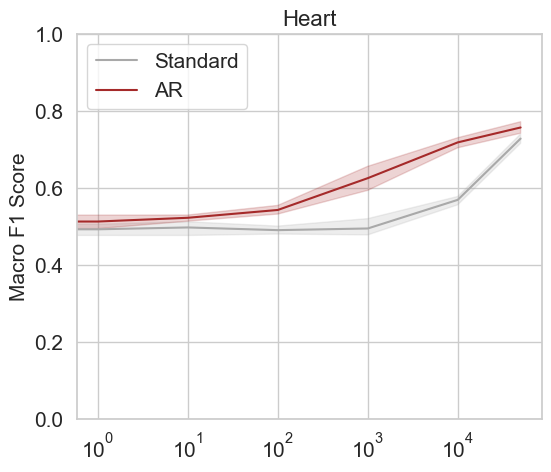

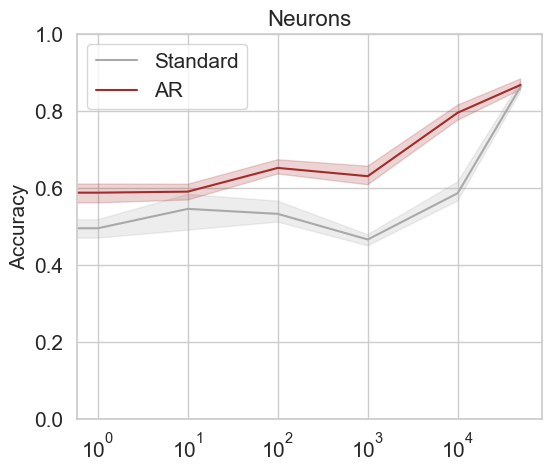

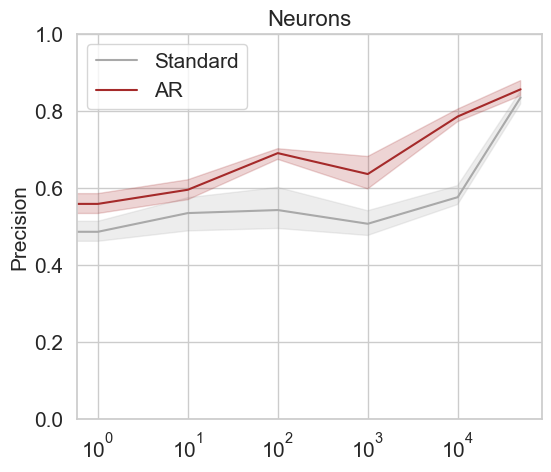

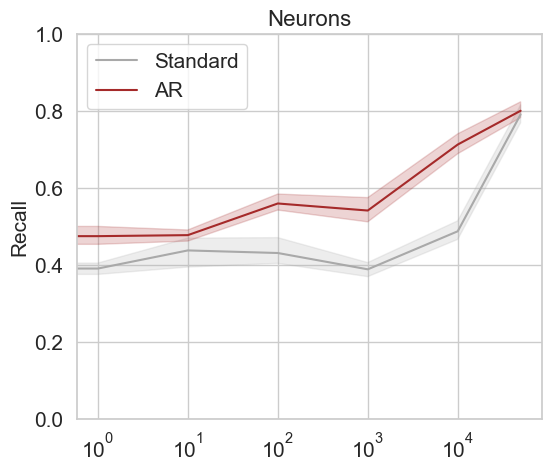

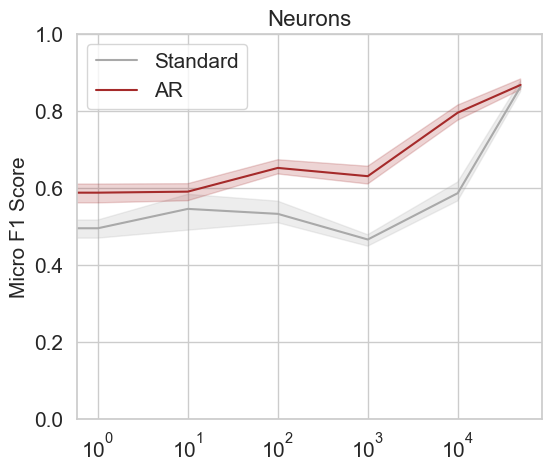

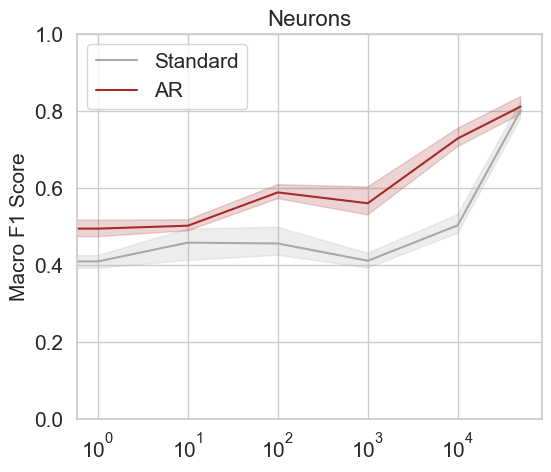

In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

palette = {'Standard': "darkgray", 'AR': "brown"}

for latent_dim_val, epoch_val in sorted(plot_df[['latent_dim', 'epoch_num']].drop_duplicates().values.tolist()):
    subset = plot_df[(plot_df['latent_dim'] == latent_dim_val) & (plot_df['epoch_num'] == epoch_val)]

    for dataset in subset['dataset'].unique():
        for i, metric in enumerate(metrics):
            fig, axs = plt.subplots(1, 1, figsize=(6, 5))
            sns.set_theme(style="whitegrid")
            g = sns.lineplot(
                data=subset[(subset['dataset'] == dataset) & (subset['metric'] == metric)],
                x="Atlas_cell_count", y="value", hue="ARtype", palette=palette,
                hue_order=['Standard', 'AR']
            )
            g.set_xlabel('')
            g.set_ylabel(metric, fontsize=15)
            g.set_title(dataset.capitalize(), fontsize=16)
            g.tick_params(axis='both', which='major', labelsize=15)
            g.tick_params(axis='both', which='minor', labelsize=15)
            g.legend(loc='upper left', fontsize=15)
            g.set(ylim=(0, 1))
            g.set_xscale("log", base=10)
            plt.savefig(
                f'/Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal/new_results/scvi/figure/scvi_plots_for_different_latentdim_epochs/latentdim{latent_dim_val}_epoch{epoch_val}/{dataset}_{metric}_latentdim{latent_dim_val}_epoch{epoch_val}.png',
                dpi=600, bbox_inches='tight'
            )
            plt.show()


Generate plot for reconstruction error

In [72]:
import pickle
import os
import pandas as pd

df = pd.DataFrame(columns=['dataset', 'metric', 'value', 'ARtype', 'Atlas_cell_count', 'seed', 'latent_dim', 'epoch'])
dir = '../result/test/sctab/scVI-reconstruction-evals-for-different-k-and-epoch/'

for file in os.listdir(dir):
    if file.endswith(".pkl") and 'Reconstruction_seed_' in file:
        parts = file.split('_')
        ARtype = parts[4]
        seed = parts[2]
        Atlas_cell_count = parts[11]
        latent_dim = int(parts[7])
        epoch = int(parts[15])
        print('ARtype:', ARtype, 'seed:', seed, 'Atlas_cell_count:', Atlas_cell_count,
              'latent_dim:', latent_dim, 'epoch:', epoch)

        with open(dir + file, "rb") as f:
            data = pickle.load(f)
            print(list(data.keys()))
            for key in list(data.keys()):
                test_df = data[key]
                print(test_df.columns)
                mean_r2 = test_df['r2'].mean()
                mean_corr = test_df['correlation'].mean()
                df.loc[len(df)] = [key, 'correlation', mean_corr, ARtype, Atlas_cell_count, seed, latent_dim, epoch]
                df.loc[len(df)] = [key, 'r2', mean_r2, ARtype, Atlas_cell_count, seed, latent_dim, epoch]

ARtype: T seed: 70 Atlas_cell_count: 100 latent_dim: 64 epoch: 150
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'supercluster_term'], dtype='object')
ARtype: T seed: 80 Atlas_cell_count: 100 latent_dim: 64 epoch: 600
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'supercluster_term'], dtype='object')
ARtype: T seed: 70 Atlas_cell_count: 0 latent_dim: 64 epoch: 600
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'supercluster_term'], dtype='

In [73]:
df

,dataset,metric,value,ARtype,Atlas_cell_count,seed,latent_dim,epoch
0,scTab_Heart_reconstruction,correlation,0.334428,T,100,70,64,150
1,scTab_Heart_reconstruction,r2,0.121931,T,100,70,64,150
2,scTab_Kidney_reconstruction,correlation,0.357345,T,100,70,64,150
3,scTab_Kidney_reconstruction,r2,0.134580,T,100,70,64,150
4,Neurons_reconstruction,correlation,0.744170,T,100,70,64,150
...,...,...,...,...,...,...,...,...
1675,scTab_Heart_reconstruction,r2,0.076613,T,10,80,32,300
1676,scTab_Kidney_reconstruction,correlation,0.174651,T,10,80,32,300
1677,scTab_Kidney_reconstruction,r2,0.046785,T,10,80,32,300
1678,Neurons_reconstruction,correlation,0.064090,T,10,80,32,300


In [74]:
# include only rows with seed in [50, 60, 70, 80, 90]
df = df[df['seed'].isin(['50', '60', '70', '80', '90'])]
print(df[df['ARtype'] == 'T'].shape[0])
print(df[df['ARtype'] == 'F'].shape[0])

print('df[df[seed] == 50].shape[0]:', df[df['seed'] == '50'].shape[0])
print('df[df[seed] == 60].shape[0]:', df[df['seed'] == '60'].shape[0])
print('df[df[seed] == 70].shape[0]:', df[df['seed'] == '70'].shape[0])
print('df[df[seed] == 80].shape[0]:', df[df['seed'] == '80'].shape[0])
print('df[df[seed] == 90].shape[0]:', df[df['seed'] == '90'].shape[0])

print('Atlas_cell_count:', df['Atlas_cell_count'].unique())
for count in ['0', '1', '10', '100', '1000', '10000', '50000']:
    print(f'Atlas_cell_count={count}:', df[df['Atlas_cell_count'] == count].shape[0])

assert df[df['ARtype'] == 'T'].shape[0] == df[df['ARtype'] == 'F'].shape[0]
assert df[df['seed'] == '50'].shape[0] \
    == df[df['seed'] == '60'].shape[0] \
    == df[df['seed'] == '70'].shape[0] \
    == df[df['seed'] == '80'].shape[0] \
    == df[df['seed'] == '90'].shape[0]

df.shape

840
840
df[df[seed] == 50].shape[0]: 336
df[df[seed] == 60].shape[0]: 336
df[df[seed] == 70].shape[0]: 336
df[df[seed] == 80].shape[0]: 336
df[df[seed] == 90].shape[0]: 336
Atlas_cell_count: ['100' '0' '50000' '10000' '10' '1000' '1']
Atlas_cell_count=0: 240
Atlas_cell_count=1: 240
Atlas_cell_count=10: 240
Atlas_cell_count=100: 240
Atlas_cell_count=1000: 240
Atlas_cell_count=10000: 240
Atlas_cell_count=50000: 240


(1680, 8)

In [75]:
# if 'heart' in df.dataset.lower, change it to 'Heart', if 'kidney' in df.dataset.lower, change it to 'Kidney'
df['dataset'] = df['dataset'].apply(lambda x: 'Heart' if 'heart' in x.lower() else x)
df['dataset'] = df['dataset'].apply(lambda x: 'Kidney' if 'kidney' in x.lower() else x)
df['dataset'] = df['dataset'].apply(lambda x: 'Neurons' if 'neuron' in x.lower() else x)

In [76]:
# replace ARtype with Standard
df['ARtype'] = df['ARtype'].apply(lambda x: 'Standard' if x == 'F' else 'AR')


=== latent_dim=32, epoch=300 ===
shape of results_df: (42, 4)
\begin{table}
\caption{P-values for Heart (latent_dim=32, epoch=300)}
\label{tab:pvalues_Heart_32_300}
\begin{tabular}{lrrrrrrr}
Atlas_cell_count & 0 & 1 & 10 & 100 & 1000 & 10000 & 50000 \\
metric &  &  &  &  &  &  &  \\
correlation & \background-colorgreen \colorwhite 1.44e-04 & \background-colorgreen \colorwhite 2.24e-05 & \background-colorgreen \colorwhite 2.76e-02 & \background-colorgreen \colorwhite 1.00e-08 & \background-colorgreen \colorwhite 2.36e-07 & \background-colorgreen \colorwhite 5.68e-10 & \background-colorgreen \colorwhite 7.81e-06 \\
r2 & \background-colorgreen \colorwhite 1.22e-03 & \background-colorgreen \colorwhite 1.29e-05 & \background-colorgreen \colorwhite 2.45e-02 & \background-colorgreen \colorwhite 2.66e-07 & \background-colorgreen \colorwhite 2.49e-07 & \background-colorgreen \colorwhite 2.36e-10 & \background-colorgreen \colorwhite 2.38e-06 \\
\end{tabular}
\end{table}

\begin{table}
\caption{

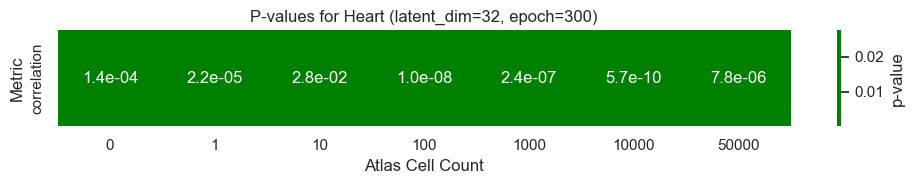

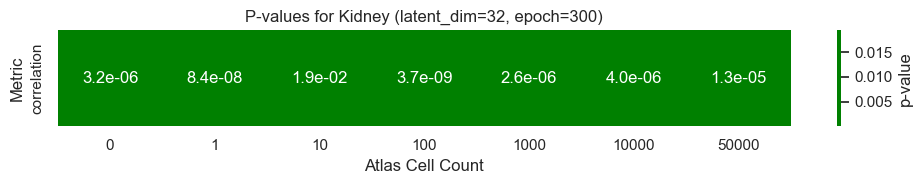

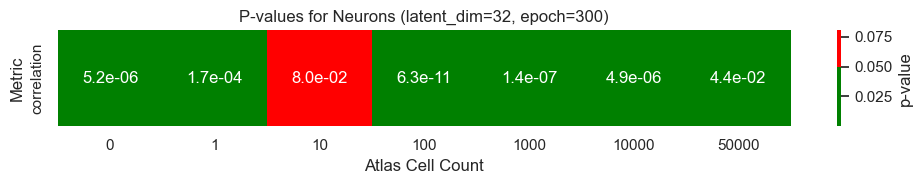


=== latent_dim=64, epoch=150 ===
shape of results_df: (42, 4)
\begin{table}
\caption{P-values for Heart (latent_dim=64, epoch=150)}
\label{tab:pvalues_Heart_64_150}
\begin{tabular}{lrrrrrrr}
Atlas_cell_count & 0 & 1 & 10 & 100 & 1000 & 10000 & 50000 \\
metric &  &  &  &  &  &  &  \\
correlation & \background-colorgreen \colorwhite 5.97e-04 & \background-colorgreen \colorwhite 2.46e-05 & \background-colorgreen \colorwhite 8.64e-04 & \background-colorgreen \colorwhite 8.75e-12 & \background-colorgreen \colorwhite 3.22e-08 & \background-colorgreen \colorwhite 2.52e-09 & \background-colorgreen \colorwhite 1.59e-07 \\
r2 & \background-colorgreen \colorwhite 3.76e-04 & \background-colorgreen \colorwhite 2.45e-05 & \background-colorgreen \colorwhite 2.01e-03 & \background-colorgreen \colorwhite 1.77e-10 & \background-colorgreen \colorwhite 5.12e-08 & \background-colorgreen \colorwhite 2.62e-09 & \background-colorgreen \colorwhite 1.11e-07 \\
\end{tabular}
\end{table}

\begin{table}
\caption{

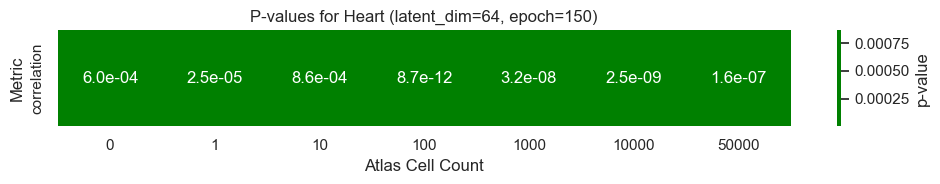

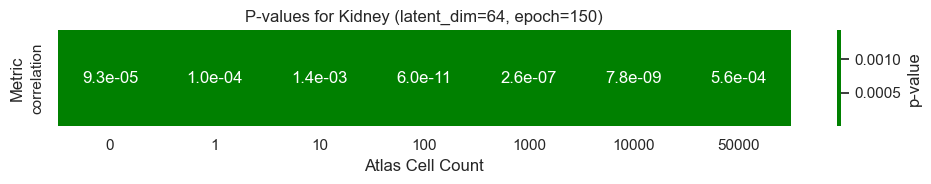

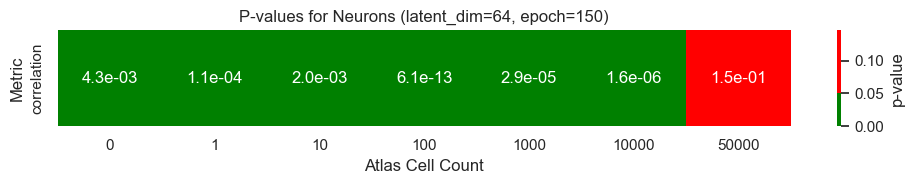


=== latent_dim=64, epoch=600 ===
shape of results_df: (42, 4)
\begin{table}
\caption{P-values for Heart (latent_dim=64, epoch=600)}
\label{tab:pvalues_Heart_64_600}
\begin{tabular}{lrrrrrrr}
Atlas_cell_count & 0 & 1 & 10 & 100 & 1000 & 10000 & 50000 \\
metric &  &  &  &  &  &  &  \\
correlation & \background-colorgreen \colorwhite 4.72e-05 & \background-colorgreen \colorwhite 3.84e-06 & \background-colorgreen \colorwhite 1.23e-04 & \background-colorgreen \colorwhite 1.22e-07 & \background-colorgreen \colorwhite 1.82e-07 & \background-colorgreen \colorwhite 2.11e-08 & \background-colorgreen \colorwhite 3.06e-06 \\
r2 & \background-colorgreen \colorwhite 1.90e-04 & \background-colorgreen \colorwhite 1.40e-05 & \background-colorgreen \colorwhite 9.65e-05 & \background-colorgreen \colorwhite 2.33e-07 & \background-colorgreen \colorwhite 3.56e-07 & \background-colorgreen \colorwhite 1.09e-08 & \background-colorgreen \colorwhite 1.37e-06 \\
\end{tabular}
\end{table}

\begin{table}
\caption{

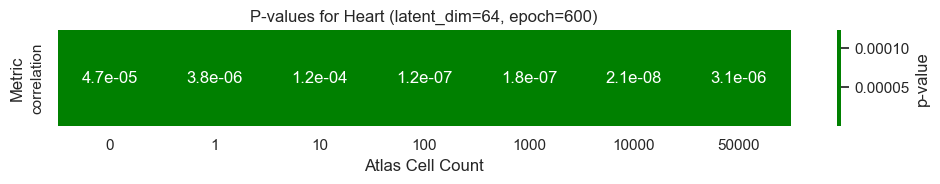

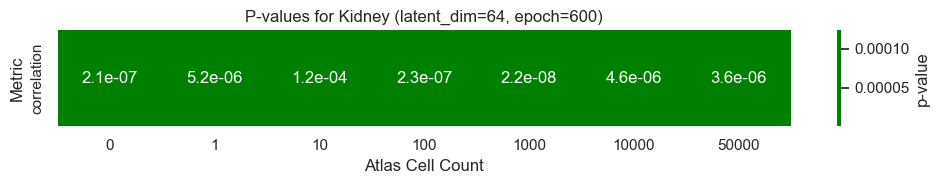

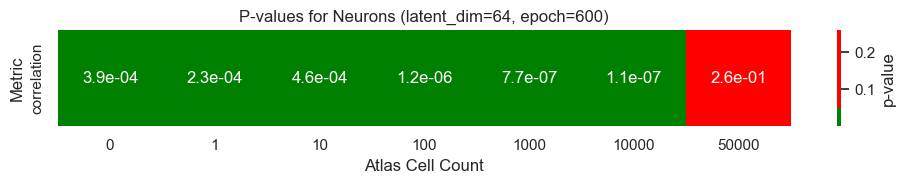


=== latent_dim=128, epoch=300 ===
shape of results_df: (42, 4)
\begin{table}
\caption{P-values for Heart (latent_dim=128, epoch=300)}
\label{tab:pvalues_Heart_128_300}
\begin{tabular}{lrrrrrrr}
Atlas_cell_count & 0 & 1 & 10 & 100 & 1000 & 10000 & 50000 \\
metric &  &  &  &  &  &  &  \\
correlation & \background-colorgreen \colorwhite 3.95e-04 & \background-colorgreen \colorwhite 7.16e-07 & \background-colorgreen \colorwhite 5.50e-04 & \background-colorgreen \colorwhite 1.55e-08 & \background-colorgreen \colorwhite 5.14e-07 & \background-colorgreen \colorwhite 2.92e-12 & \background-colorgreen \colorwhite 9.32e-09 \\
r2 & \background-colorgreen \colorwhite 1.14e-03 & \background-colorgreen \colorwhite 3.66e-06 & \background-colorgreen \colorwhite 1.22e-03 & \background-colorgreen \colorwhite 9.72e-07 & \background-colorgreen \colorwhite 3.04e-07 & \background-colorgreen \colorwhite 1.11e-11 & \background-colorgreen \colorwhite 1.73e-09 \\
\end{tabular}
\end{table}

\begin{table}
\capti

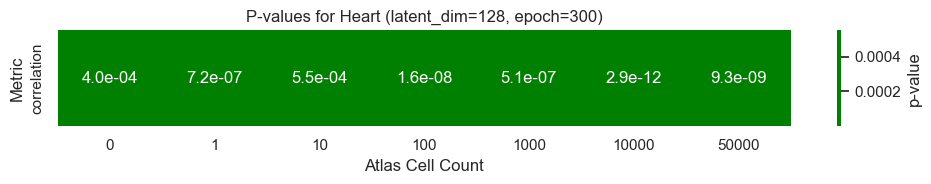

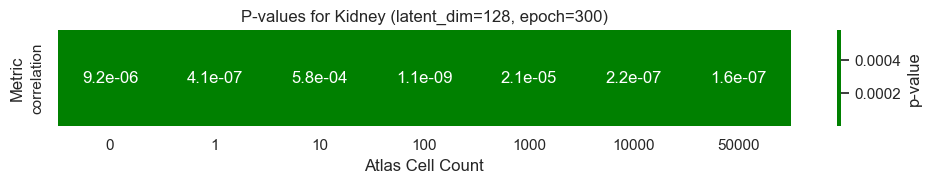

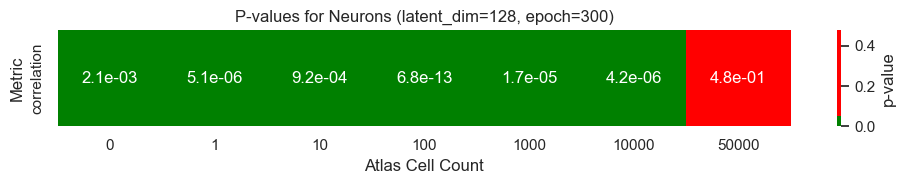

In [77]:
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

for latent_dim_val, epoch_val in sorted(df[['latent_dim', 'epoch']].drop_duplicates().values.tolist()):
    subset = df[(df['latent_dim'] == latent_dim_val) & (df['epoch'] == epoch_val)]

    print(f"\n=== latent_dim={latent_dim_val}, epoch={epoch_val} ===")

    # compute p-values between AR and Standard using t-test
    results = []
    for dataset in subset['dataset'].unique():
        for metric in subset['metric'].unique():
            for atlas_cell_count in subset['Atlas_cell_count'].unique():
                ar_values = subset[
                    (subset['dataset'] == dataset) &
                    (subset['metric'] == metric) &
                    (subset['Atlas_cell_count'] == atlas_cell_count) &
                    (subset['ARtype'] == 'AR')
                ]['value']
                naive_values = subset[
                    (subset['dataset'] == dataset) &
                    (subset['metric'] == metric) &
                    (subset['Atlas_cell_count'] == atlas_cell_count) &
                    (subset['ARtype'] == 'Standard')
                ]['value']
                assert ar_values.shape == naive_values.shape
                if len(ar_values) > 1 and len(naive_values) > 1:
                    t_stat, p_value = stats.ttest_ind(ar_values, naive_values)
                    results.append([dataset, metric, atlas_cell_count, p_value])
                else:
                    results.append([dataset, metric, atlas_cell_count, None])

    # print LaTeX table for each dataset
    results_df = pd.DataFrame(results, columns=['dataset', 'metric', 'Atlas_cell_count', 'p_value'])
    print('shape of results_df:', results_df.shape)

    for dataset in results_df['dataset'].unique():
        sub = results_df[results_df['dataset'] == dataset]
        pivot_table = sub.pivot(index='metric', columns='Atlas_cell_count', values='p_value')
        def color_pval(val):
            if pd.isna(val): return ''
            elif val < 0.05: return 'background-color: green; color: white;'
            else: return 'background-color: yellow; color: black;'
        styled_table = pivot_table.style.map(color_pval).format(precision=2, formatter="{:.2e}")
        latex_table = styled_table.to_latex(
            caption=f'P-values for {dataset} (latent_dim={latent_dim_val}, epoch={epoch_val})',
            label=f'tab:pvalues_{dataset}_{latent_dim_val}_{epoch_val}'
        )
        print(latex_table)

    # plot heatmap of p-values for correlation metric
    results_df_corr = results_df[results_df['metric'].isin(['correlation'])]
    for dataset in results_df_corr['dataset'].unique():
        pivot_df = results_df_corr[results_df_corr['dataset'] == dataset].pivot(
            index='metric', columns='Atlas_cell_count', values='p_value'
        )
        plt.figure(figsize=(10, 2))
        sns.heatmap(pivot_df, annot=True, fmt=".1e",
                    cmap=sns.color_palette(["green", "red"]), center=0.05,
                    cbar_kws={'label': 'p-value'})
        plt.title(f'P-values for {dataset} (latent_dim={latent_dim_val}, epoch={epoch_val})')
        plt.xlabel('Atlas Cell Count')
        plt.ylabel('Metric')
        plt.axhline(y=-0.5, color='black', linewidth=2)
        plt.axvline(x=-0.5, color='black', linewidth=2)
        plt.tight_layout()
        plt.show()

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_92630/2270487760.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


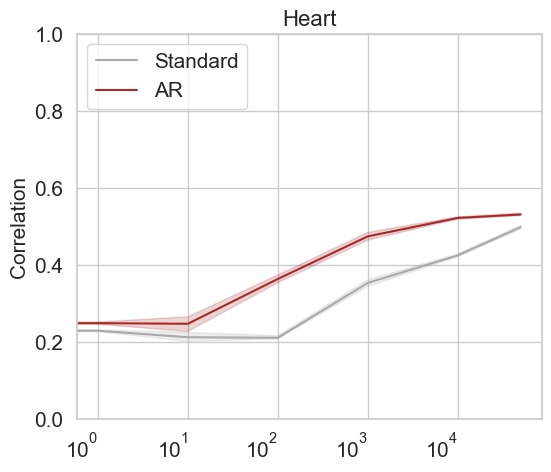

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_92630/2270487760.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


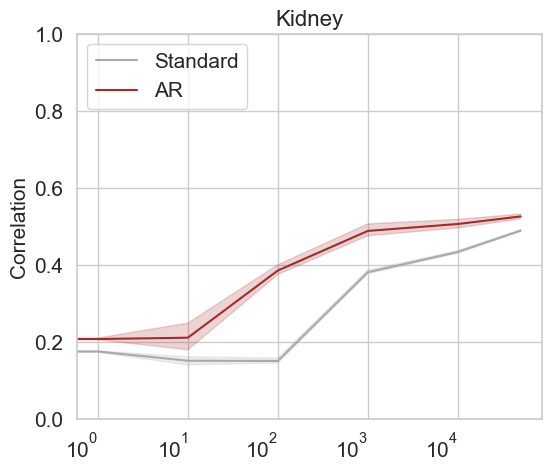

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_92630/2270487760.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


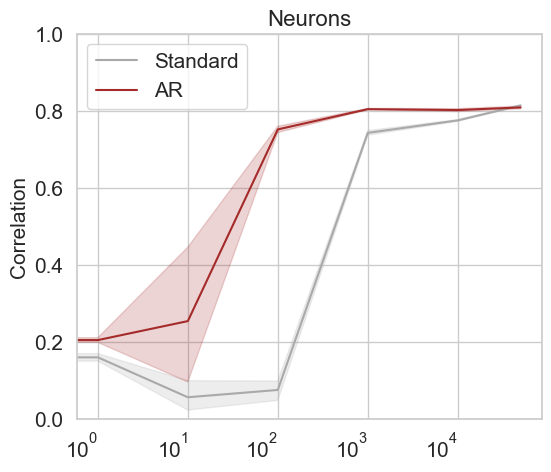

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_92630/2270487760.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


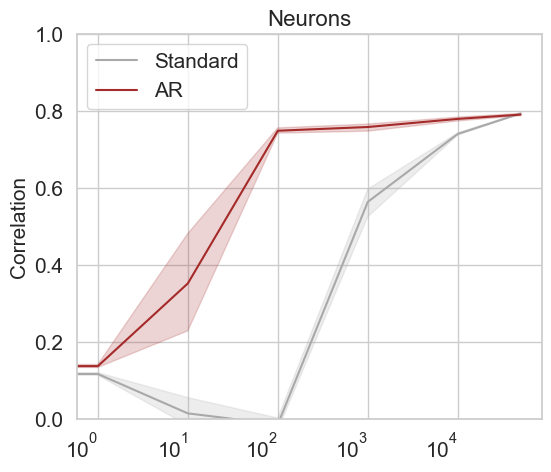

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_92630/2270487760.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


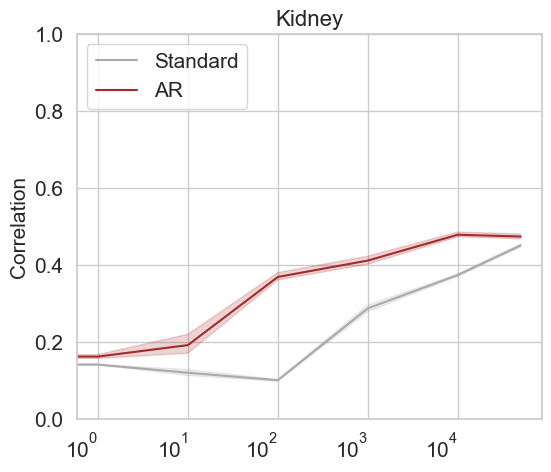

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_92630/2270487760.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


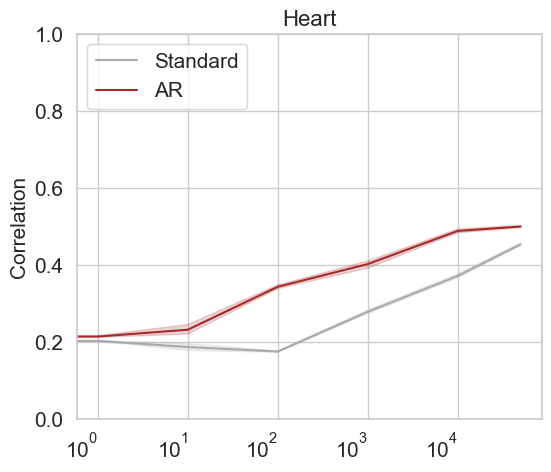

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_92630/2270487760.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


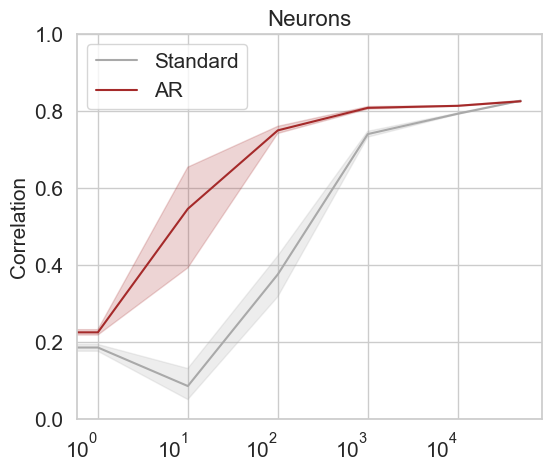

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_92630/2270487760.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


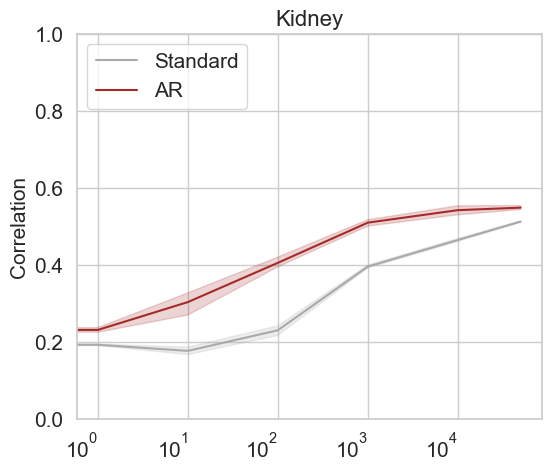

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_92630/2270487760.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


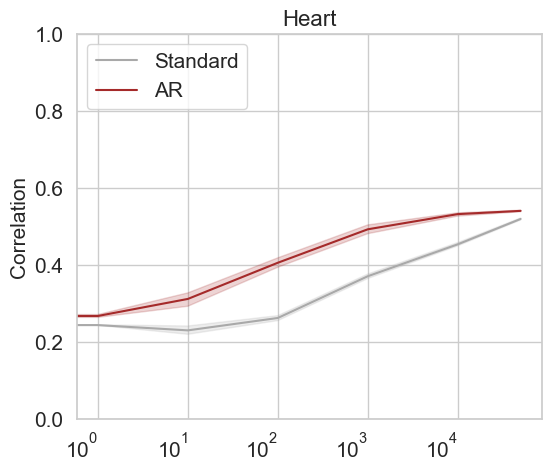

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_92630/2270487760.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


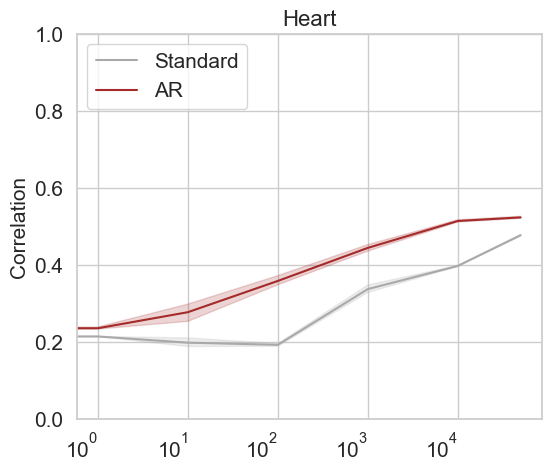

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_92630/2270487760.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


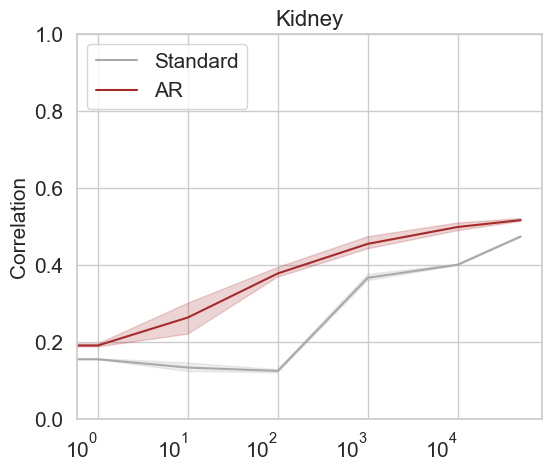

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_92630/2270487760.py:21: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


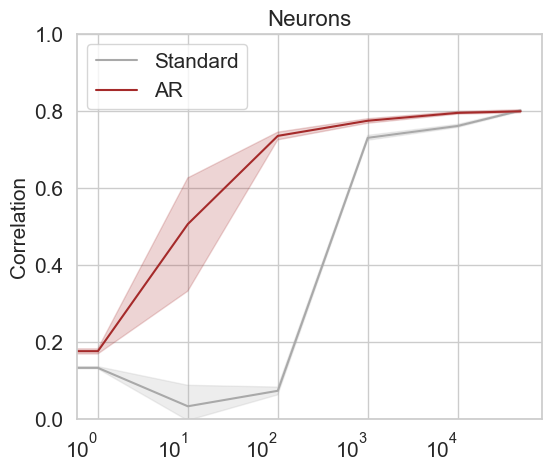

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt

df['Atlas_cell_count'] = df['Atlas_cell_count'].astype(int)
df = df.sort_values(by='Atlas_cell_count')

palette = {'Standard': "darkgray", 'AR': "brown"}

for latent_dim_val, epoch_val in sorted(df[['latent_dim', 'epoch']].drop_duplicates().values.tolist()):
    subset = df[(df['latent_dim'] == latent_dim_val) & (df['epoch'] == epoch_val)]

    for dataset in subset['dataset'].unique():
        for i, metric in enumerate(['correlation']):
            fig, axs = plt.subplots(1, 1, figsize=(6, 5))
            sns.set_theme(style="whitegrid")
            g = sns.lineplot(
                data=subset[(subset['dataset'] == dataset) & (subset['metric'] == metric)],
                x="Atlas_cell_count", y="value", hue="ARtype", palette=palette,
                hue_order=['Standard', 'AR']
            )
            g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')
            g.set_xlabel('')
            g.set_ylabel(metric.capitalize(), fontsize=15)
            g.set_title(dataset.capitalize(), fontsize=16)
            g.tick_params(axis='both', which='major', labelsize=15)
            g.tick_params(axis='both', which='minor', labelsize=15)
            g.set_xscale("log", base=10)
            g.legend(loc='upper left', fontsize=15)
            g.set(ylim=(0, 1))
            plt.savefig(
                f'/Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal/new_results/scvi/figure/scvi_plots_for_different_latentdim_epochs/latentdim{latent_dim_val}_epoch{epoch_val}/{dataset}_{metric}_latentdim{latent_dim_val}_epoch{epoch_val}.png',
                dpi=600, bbox_inches='tight'
            )
            plt.show()